In [1]:
import pandas as pd
import scipy.stats as st

In [2]:
df2 = pd.read_csv('../Statistic/data/5_task_2.csv')
df1 = pd.read_csv('../Statistic/data/5_task_1.csv')

In [3]:
df1['group'].unique()

array(['A', 'B', 'C'], dtype=object)

In [4]:
df2['group'].unique()

array(['test', 'control'], dtype=object)

In [5]:
df1.head()

,id,group,events
0,16046,A,14
1,18712,A,41
2,3268,A,30
3,22633,A,37
4,28071,A,38


In [6]:
df2.head()

,id,group,segment,events
0,83440,test,high,78.0
1,96723,test,high,71.0
2,68719,test,high,80.0
3,50399,test,high,80.0
4,95613,test,high,78.0


In [7]:
control = df2[df2.group == 'control'].events
test = df2[df2.group == 'test'].events
test_B = df1[df1.group == 'B'].events
test_C = df1[df1.group == 'C'].events
test_A = df1[df1.group == 'A'].events

In [8]:
st.levene(control, test)

LeveneResult(statistic=np.float64(2.5440050816535327), pvalue=np.float64(0.11071679229795423))

In [9]:
st.levene(test_A, test_B)

LeveneResult(statistic=np.float64(4.084379401077022), pvalue=np.float64(0.04329464094557965))

In [10]:
st.levene(test_A, test_C)

LeveneResult(statistic=np.float64(0.2091714847451484), pvalue=np.float64(0.6474225304290779))

In [11]:
st.levene(test_B, test_C)

LeveneResult(statistic=np.float64(2.5032171195157384), pvalue=np.float64(0.11362981136092266))

group
A    Axes(0.125,0.11;0.775x0.77)
Name: events, dtype: object

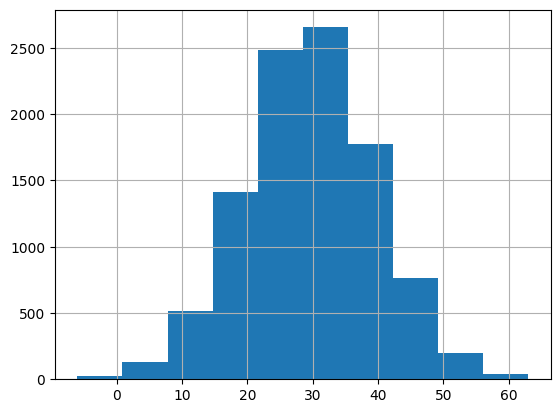

In [12]:
df1[df1.group == 'A'].groupby("group").events.hist()

group
B    Axes(0.125,0.11;0.775x0.77)
Name: events, dtype: object

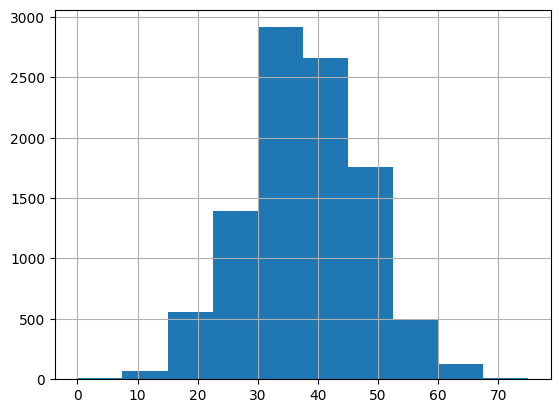

In [13]:
df1[df1.group == 'B'].groupby("group").events.hist()

group
C    Axes(0.125,0.11;0.775x0.77)
Name: events, dtype: object

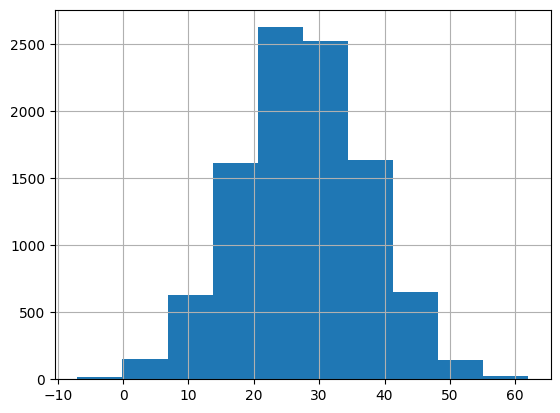

In [14]:
df1[df1.group == 'C'].groupby("group").events.hist()

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

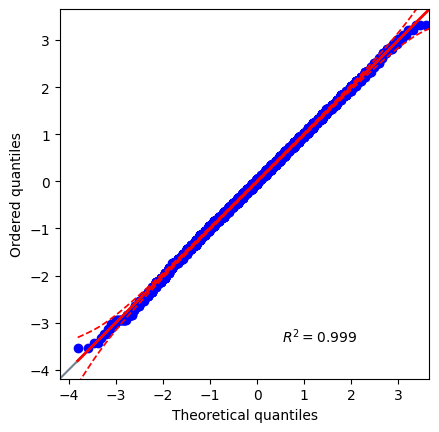

In [15]:
import pingouin as pg
pg.qqplot(df1[df1.group == 'A'].events)



In [16]:
pingouin.qqplot(df1[df1.group == 'B'].events)

NameError: name 'pingouin' is not defined

<Axes: xlabel='Theoretical quantiles', ylabel='Ordered quantiles'>

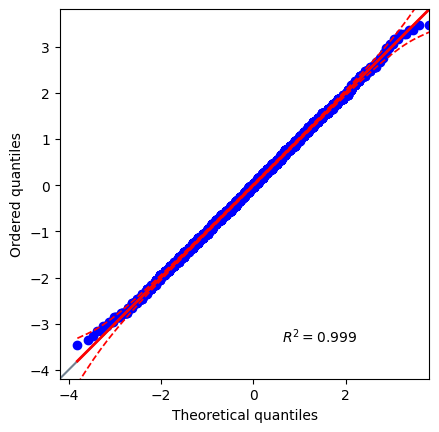

In [ ]:
pingouin.qqplot(df1[df1.group == 'C'].events)

In [ ]:
pg.anova(data=df2, 
         dv="events", 
         between="group")

,Source,ddof1,ddof2,F,p-unc,np2
0,group,1,99998,14166.221355,0.0,0.124086


In [ ]:
pg.anova(data=df1, 
         dv="events", 
         between="group")

,Source,ddof1,ddof2,F,p-unc,np2
0,group,2,29997,2886.166657,0.0,0.161377


In [ ]:
pg.pairwise_tukey(data=df1, dv="events", between="group")

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,A,B,29.5796,37.6136,-8.0340,0.140894,-57.021604,0.0,-0.806229
1,A,C,29.5796,27.4703,2.1093,0.140894,14.970833,0.0,0.210514
2,B,C,37.6136,27.4703,10.1433,0.140894,71.992436,0.0,1.024138


In [ ]:
pg.pairwise_gameshowell(data=df1, dv="events", between="group")




,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,A,B,29.5796,37.6136,-8.0340,0.140920,-57.011134,19987.258491,6.412648e-13,-0.806229
1,A,C,29.5796,27.4703,2.1093,0.141696,14.886135,19995.116233,0.000000e+00,0.210514
2,B,C,37.6136,27.4703,10.1433,0.140062,72.420220,19995.502469,0.000000e+00,1.024138


segment
high    Axes(0.125,0.11;0.775x0.77)
low     Axes(0.125,0.11;0.775x0.77)
Name: events, dtype: object

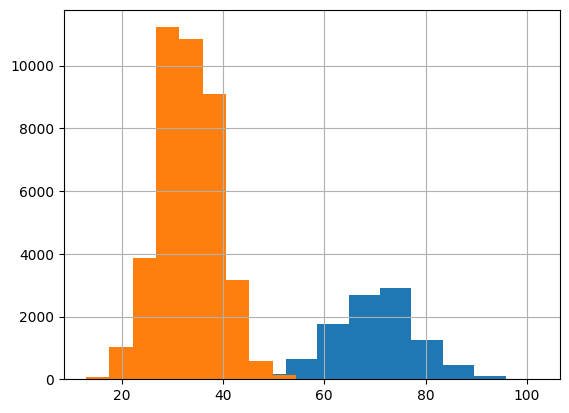

In [ ]:
df2[df2.group == 'test'].groupby("segment").events.hist()

segment
high    Axes(0.125,0.11;0.775x0.77)
low     Axes(0.125,0.11;0.775x0.77)
Name: events, dtype: object

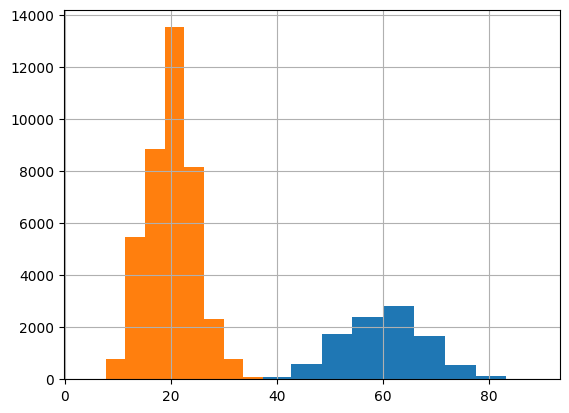

In [ ]:
df2[df2.group == 'control'].groupby("segment").events.hist()

In [ ]:
df2[df2.group == 'control'].groupby("segment").describe()

id                                                               \
           count        mean           std   min       25%      50%       75%   
segment                                                                         
high     10000.0  50473.9782  28761.438914  10.0  25612.50  51031.0  75261.25   
low      40000.0  49935.2567  28855.849243   0.0  25022.25  49944.5  74874.25   

                   events                                                     
             max    count       mean       std   min   25%   50%   75%   max  
segment                                                                       
high     99976.0  10000.0  59.970800  7.805347  31.0  55.0  60.0  65.0  89.0  
low      99999.0  40000.0  20.031575  4.473576   4.0  17.0  20.0  23.0  41.0

In [ ]:
df2_anova = pg.anova(data=df2, dv="events", between=["segment", "group"])

,Source,SS,DF,MS,F,p-unc,np2
0,segment,2.362480e+07,1.0,2.362480e+07,689756.377484,0.000000e+00,0.873383
1,group,3.837195e+06,1.0,3.837195e+06,112031.864119,0.000000e+00,0.528383
2,segment * group,3.664244e+04,1.0,3.664244e+04,1069.823273,2.060261e-233,0.010585
3,Residual,3.424956e+06,99996.0,3.425093e+01,NaN,NaN,NaN


In [ ]:
df2_tukey = pg.pairwise_gameshowell(data=df2, dv="events", between="group")

In [ ]:
df2_tukey

,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,control,test,28.01942,40.40844,-12.38902,0.10409,-119.021936,99783.716091,4.047207e-11,-0.752755


In [ ]:
df2["combination"] = df2.group + "/" + df2.segment

In [ ]:
df2_tukey = pg.pairwise_tukey(data=df2, dv="events", between="combination")

In [ ]:
df2_tukey

,A,B,mean(A),mean(B),diff,se,T,p-tukey,hedges
0,control/high,control/low,59.970800,20.031575,39.939225,0.065432,610.391461,1.010172e-10,7.521612
1,control/high,test/high,59.970800,69.938500,-9.967700,0.082766,-120.432523,1.010172e-10,-1.228989
2,control/high,test/low,59.970800,33.025925,26.944875,0.065432,411.798717,1.010172e-10,4.350026
3,control/low,test/high,20.031575,69.938500,-49.906925,0.065432,-762.727892,1.010172e-10,-9.091140
4,control/low,test/low,20.031575,33.025925,-12.994350,0.041383,-314.002699,1.010172e-10,-2.530414
5,test/high,test/low,69.938500,33.025925,36.912575,0.065432,564.135148,1.010172e-10,5.814008


<Axes: xlabel='group', ylabel='events'>

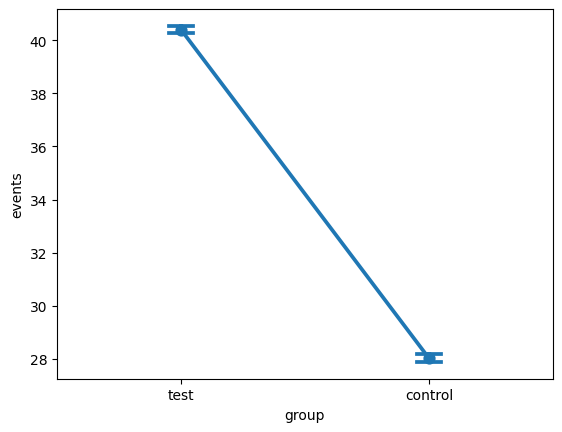

In [17]:
import seaborn as sns
sns.pointplot(x="group", #название группирующей переменной
              y="events", #название переменной, которую мы сравниваем
              data=df2, #датафрейм с данными
              capsize=0.1) #длина засечек на конце "усов" - можно убрать

<Axes: xlabel='segment', ylabel='events'>

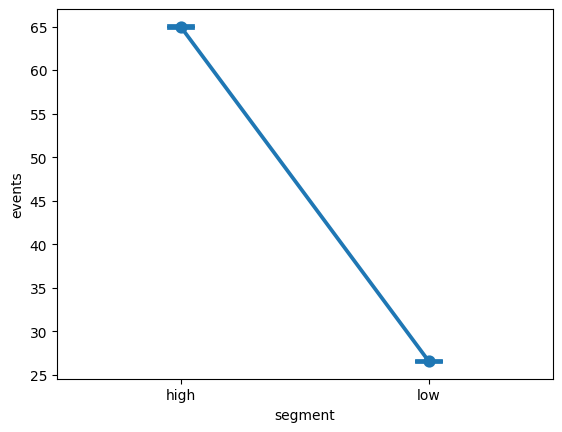

In [18]:
sns.pointplot(x="segment", #название группирующей переменной
              y="events", #название переменной, которую мы сравниваем
              data=df2, #датафрейм с данными
              capsize=0.1) #длина засечек на конце "усов" - можно убрать

<Axes: >

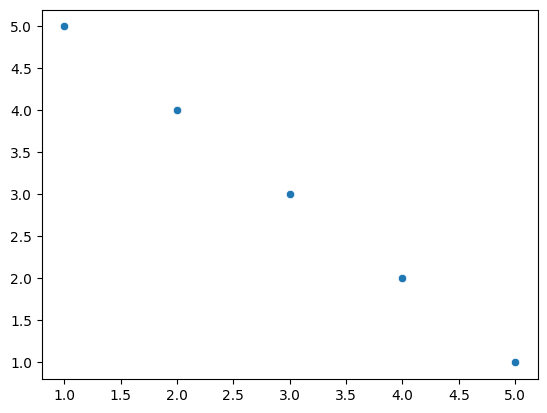

In [1]:
import seaborn as sns
sns.scatterplot(x=[4, 5, 2, 3, 1], y=[2, 1, 4, 3, 5])

In [2]:
import scipy.stats as st
st.pearsonr(x=[4, 5, 2, 3, 1], y=[2, 1, 4, 3, 5])

PearsonRResult(statistic=np.float64(-1.0), pvalue=np.float64(0.0))